<a href="https://colab.research.google.com/github/Sakith-N/Statistical-Learning-e22252/blob/assignment-1/Q10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.$f_{T,P}(t, p) = \frac{1}{\sqrt{2\pi}}e^{-\frac{t^2}{2}} . \frac{1}{\sqrt{2\pi(4)}}e^{-\frac{p^2}{2(4)}}$

2.$\sigma(X) = \{ A \times \mathbb{R} : A \in \mathfrak{B}(\mathbb{R})\}$

3.$\sigma(Y) = \mathfrak{B}(\mathbb{R}^2)$

4.Mathematically, $\sigma(X) \subseteq \sigma(Y)$ because X is a direct projection of Y. In the 2D sample space $\mathbb{R}^2$, every event in $\sigma(X)$ is a vertical strip, which is also a valid Borel set in $\sigma(Y)$.

Y contains more information because it provides the full state in both Temperature and Pressure, allowing to pinpoint a specific point in the state space. however, X only provides the Temperature, leaving the Pressure completely unknown

In [6]:
import numpy as np
from scipy.stats import norm

def get_marginal_x(x_val):     # fx(x) is the standard normal PDF
    return norm.pdf(x_val, loc=0, scale=1)

def get_marginal_y(t_val, p_val):      # fy(t, p) is the joint PDF (product of independent T and P)
    f_t = norm.pdf(t_val,loc=0,scale=1)
    f_p = norm.pdf(p_val,loc=0,scale=2)
    return f_t*f_p

# Example evaluations at the center (0, 0)
val_5 = get_marginal_x(0)
val_6 = get_marginal_y(0, 0)

print(f"5.Density of X at 0 (fx(x)): {val_5:.4f}")
print(f"6.Density of Y at (0,0) (fy(t,p)): {val_6:.4f}")

5.Density of X at 0 (fx(x)): 0.3989
6.Density of Y at (0,0) (fy(t,p)): 0.0796


In [7]:
from scipy.stats import norm

mu_t,sigma_t = 0, 1
mu_p,sigma_p = 0, 2

# 1.P(X <= 0)
prob_1 = norm.cdf(0,mu_t,sigma_t)

# 2.P(X > 1)
prob_2 = 1 - norm.cdf(1,mu_t,sigma_t)

# 3.P(Y in (-inf,0] x R)
prob_3 = norm.cdf(0,mu_t,sigma_t)

# 4.P(Y in [-1,1] x [-2,2])
prob_t_range = norm.cdf(1,mu_t,sigma_t) - norm.cdf(-1,mu_t,sigma_t)
prob_p_range = norm.cdf(2,mu_p,sigma_p) - norm.cdf(-2,mu_p,sigma_p)
prob_4 = prob_t_range*prob_p_range

print("7.")
print(f"P(X<=0) = {prob_1:.4f}")
print(f"P(X>1) = {prob_2:.4f}")
print(f"P(Y in (-inf, 0] x R) = {prob_3:.4f}")
print(f"P(Y in [-1, 1] x [-2, 2]) = {prob_4:.4f}")

7.
P(X<=0) = 0.5000
P(X>1) = 0.1587
P(Y in (-inf, 0] x R) = 0.5000
P(Y in [-1, 1] x [-2, 2]) = 0.4661


8. Y = (T,P) and X = T. X is a direct component of Y.If Y = (t,p), then X must equal t with probability 1. The conditional distribution is a Dirac delta distribution centered at t:
$f_{X|Y}(x | t, p) = \delta(x - t)$.
This means the conditional distributiton of X given Y is 0.

9. By the condition,T is fixed to the value t.Because T and P are independent..The conditional distribution of Y given X=t is:$Y | X=t \sim (t, P) \text{ where } P \sim N(0, 4)$
Formally, the joint conditional density is:
$f_{Y|X}(t, p | t) = f_P(p) = \frac{1}{\sqrt{8\pi}} e^{-\frac{p^2}{8}}$

10. Condition on X=t means we gain exact knowledge of the temperature deviation.this means we can identify the reactor's thermal state, but the pressure remains completely uncertain.

condition on Y=(t,p) means the additional information that becomes available is the exact pressure deviation. This provides a complete picture of the reactor's sensor state.

11. Y(ω) = (t, p) is the      identity mapping on the sample space $\Omega = \mathbb{R}^2$.

  π1(t, p) = t

  $(\pi_1 \circ Y)(t, p) = \pi_1(Y(t, p)) = \pi_1(t, p) = t$

  since X(t,p)=t ,we proved that X= $ \pi_1 \circ Y$.


12.


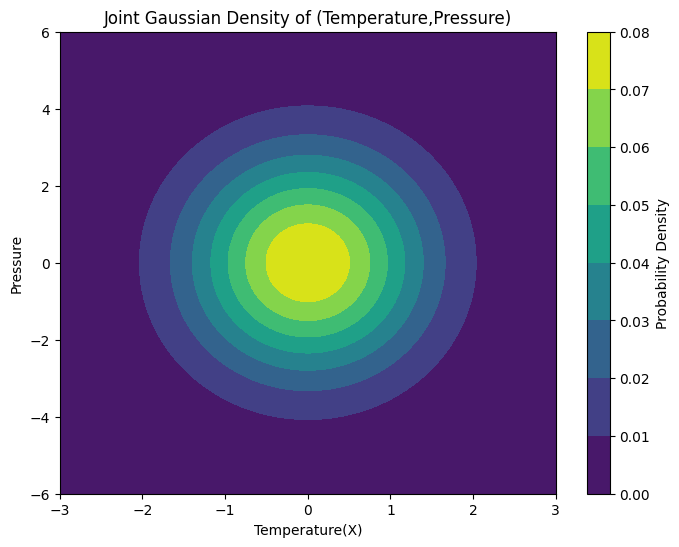

13.Differential Entropy h(X): 1.4189
14.Differential Entropy h(Y): 3.5310
15.Conditional Entropy h(Y|X): 2.1121 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Parameters
mean = [0, 0]
cov = [[1, 0], [0, 4]]

# 12. Visualization of Joint Density
t = np.linspace(-3,3,100)
p = np.linspace(-6,6,100)
T,P = np.meshgrid(t,p)
pos = np.dstack((T,P))
rv = multivariate_normal(mean,cov)

print("12.")
plt.figure(figsize=(8,6))
plt.contourf(T,P,rv.pdf(pos),cmap='viridis')
plt.title('Joint Gaussian Density of (Temperature,Pressure)')
plt.xlabel('Temperature(X)')
plt.ylabel('Pressure')
plt.colorbar(label='Probability Density')
plt.show()

#13,14,15. Entropy Calculations
h_x = 0.5*np.log(2*np.pi*np.e*1)
h_p = 0.5*np.log(2*np.pi*np.e *4)
h_y = h_x + h_p
h_y_given_x = h_y - h_x

print(f"13.Differential Entropy h(X): {h_x:.4f}")
print(f"14.Differential Entropy h(Y): {h_y:.4f}")
print(f"15.Conditional Entropy h(Y|X): {h_y_given_x:.4f} ")

16.In the discrete case, if Y determines X,H(X|Y) = 0. However,in the continuous case,the conditional distribution is a Dirac delta distribution. The differential entropy h(X|Y) technically goes to  $-\infty$ . This indicates that a point observation in a continuous space provides infinity relative to a continuous distribution